# Practice Material, Part 2, with solutions

## Final Exam, 46-921

Fall 2020

## Comments

This is a **scaled-back** version of the 2019 Final Exam. **Let me stress that the 2019 final exam was longer than this.**

There are places where the students were asked to insert code, and submit the Jupyter notebook. In our case, you will only be asked to submit written responses to questions. Hence, some modification to the style will be required. Still, you can expect to be asked to perform similar analyses.

## The Data

In this exam, we will work with a data set from Kaggle on gas prices in Brazil. The site is https://www.kaggle.com/matheusfreitag/gas-prices-in-brazil.

The following description is provided:

"The National Agency of Petroleum, Natural Gas and Bio fuels (ANP in Portuguese) releases weekly reports of gas, diesel and other fuels prices used in transportation across the country. These datasets bring the mean value per liter, number of gas stations analyzed and other information grouped by regions and states across the country."

This notebook incorporates elements of the analyses performed in https://www.kaggle.com/rafatrock/gas-prices-in-brazil-a37845a8be and https://www.kaggle.com/egenaz/gas-prices-in-brazil-eda.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Download the data set from the Canvas folder. The following command will read in the data set.

In [3]:
df = pd.read_csv('2004-2019.tsv', sep='\t', parse_dates=[1,2])

The following commands removes the first column, since it is unnecessary.

In [4]:
gp = df.drop("Unnamed: 0", axis=1)

The code below translates variables names and values from Portuguese to English.

In [5]:
gp.rename(
    columns={
        "DATA INICIAL": "start_date",
        "DATA FINAL": "end_date",
        "REGIÃO": "region",
        "ESTADO": "state",
        "PRODUTO": "fuel",
        "NÚMERO DE POSTOS PESQUISADOS": "n_gas_stations",
        "UNIDADE DE MEDIDA": "unit",
        "PREÇO MÉDIO REVENDA": "avg_price",
        "DESVIO PADRÃO REVENDA": "sd_price",
        "PREÇO MÍNIMO REVENDA": "min_price",
        "PREÇO MÁXIMO REVENDA": "max_price",
        "MARGEM MÉDIA REVENDA": "avg_price_margin",
        "ANO": "year",
        "MÊS": "month",
        "COEF DE VARIAÇÃO DISTRIBUIÇÃO": "coef_dist",
        "PREÇO MÁXIMO DISTRIBUIÇÃO": "dist_max_price",
        "PREÇO MÍNIMO DISTRIBUIÇÃO": "dist_min_price",
        "DESVIO PADRÃO DISTRIBUIÇÃO": "dist_sd_price",
        "PREÇO MÉDIO DISTRIBUIÇÃO": "dist_avg_price",
        "COEF DE VARIAÇÃO REVENDA": "coef_price"
    },
    inplace=True
)


regions = {"SUL":"SOUTH", "SUDESTE":"SOUTHEAST", "CENTRO OESTE":"MIDWEST", 
            "NORTE":"NORTH", "NORDESTE":"NORTHEAST"}
gp["region"] = gp.region.map(regions)


fuels = {"ÓLEO DIESEL":"DIESEL", "GASOLINA COMUM":"REGULAR GASOLINE", "GLP":"LPG", 
            "ETANOL HIDRATADO":"HYDROUS ETHANOL", "GNV":"NATURAL GAS", "ÓLEO DIESEL S10":"DIESEL S10"}
gp["fuel"] = gp.fuel.map(fuels)

This will convert some of the columns into numeric form.

In [6]:
for col in ['avg_price_margin', 'dist_avg_price', 'dist_sd_price', 'dist_min_price', 'dist_max_price', 'coef_dist']:
    gp[col] = pd.to_numeric(gp[col], errors='coerce')

Here are the columns as currently named in the data frame:

1. **start_date**: The starting date for the week.
2. **end_date**: The ending date for the week.
3. **region**: Region of the country for this state.
4. **state**: Brazil is divided into states; this is the state for this set of observations.
5. **fuel**: The type of gas being measured/priced.
6. **n_gas_stations**: Number of gas stations.
7. **unit**: Units for the price measurements.
8. **avg_price**: The average gas price across the stations.
9. **sd_price**: The standard deviation of the prices across the stations.
10. **min_price**: The minimum price across the stations.
11. **max_price**: The maximum price across the stations.
12. **avg_price_margin**: The difference between the average price at the stations and the distributor's average price.
13. **coef_price**: The coefficient of variation in the prices, i.e., the ratio between the standard deviation and the average price.
14. **dist_avg_price**: The average gas price from the distributors.
15. **dist_sd_price**: The standard deviation of the prices across the distributors.
16. **dist_min_price**: The minimum price across the distributors.
17. **dist_max_price**: The maximum price across the distributors.
18. **coef_dist**: The coefficient of variation across the distributor prices.
19. **month**: The month of the observations.
20. **year**: The year of the observations.

For this exam we will restrict to only the rows corresponding to natural gas. The command below will extract the appropriate subset of the data. **FOR THE ANALYSIS THAT FOLLOWS, ONLY USE THIS NATURAL GAS DATA SET.**

In [7]:
natgas = gp.loc[gp['fuel']=='NATURAL GAS',:]

del gp

## Part 0: Exploring the Data

**Question 1:** Create a figure that shows how the distribution of `avg_price` changes over the years of the data set. **(5)**

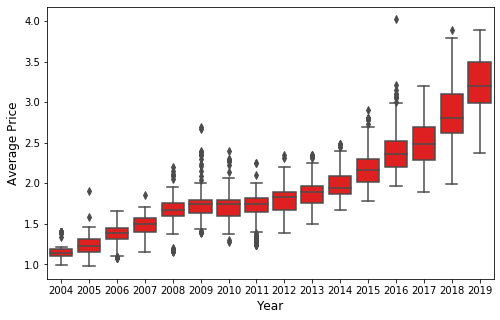

In [8]:
plt.figure(figsize=[8,5])
ax = sns.boxplot(x="year", y="avg_price", data=natgas,color="red")
plt.xlabel("Year",size=12)
plt.ylabel("Average Price",size=12)
plt.show()

**Question 2:** Does there seem to be an annual cycle in `avg_price`? Create **one** relevant plot to address this question, and comment on it. **(5)**

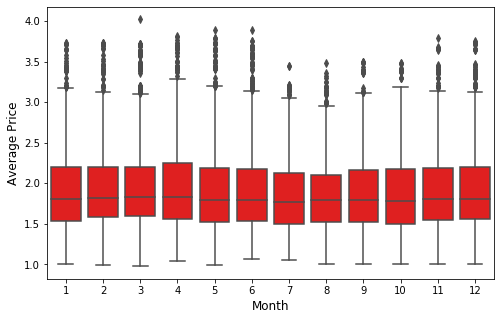

In [9]:
plt.figure(figsize=[8,5])
ax = sns.boxplot(x="month", y="avg_price", data=natgas,color="red")
plt.xlabel("Month",size=12)
plt.ylabel("Average Price",size=12)
plt.show()

There is no evidence of an annual cycle in this plot.

**Question 3:** What does the following output tell us about the data set? **(3)**

In [10]:
len(np.unique(np.where(natgas.isnull())[0]))

2028

There are 2028 rows in the data set that have at least one missing value.

**Question 4:** Consider the plot below. What does it tell us about the pattern of missing data in this data set? **(2)**

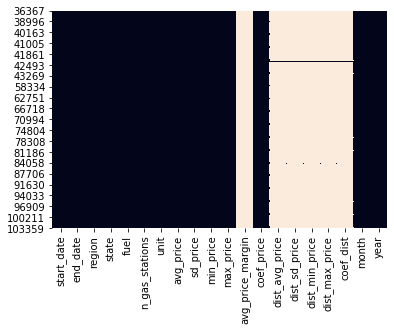

In [11]:
sns.heatmap(natgas.iloc[np.unique(np.where(natgas.isnull())[0]),:].isnull(),cbar=False)
None

It's apparent that there are some rows for which the distributor price information is not available; the lack of this information explains almost all of the missing rows.

**Question 5:** Consider the following row from the data frame. Imagine that the 29 gas stations represented here are a random sample drawn the (much larger) population of gas stations in the state. Use the provided information to construct a 95% confidence interval for the average price across all gas stations in this state, in May 2004. **(4)**

In [12]:
natgas.iloc[5,:]

start_date          2004-05-09 00:00:00
end_date            2004-05-15 00:00:00
region                        NORTHEAST
state                        PERNAMBUCO
fuel                        NATURAL GAS
n_gas_stations                       29
unit                              R$/m3
avg_price                         1.147
sd_price                          0.008
min_price                         1.108
max_price                         1.149
avg_price_margin                  0.288
coef_price                        0.007
dist_avg_price                    0.859
dist_sd_price                     0.094
dist_min_price                   0.7097
dist_max_price                   0.9221
coef_dist                         0.109
month                                 5
year                               2004
Name: 36201, dtype: object

In [13]:
from scipy.stats import norm

print(1.147 - norm.ppf(0.975)*0.008/np.sqrt(29))
print(1.147 + norm.ppf(0.975)*0.008/np.sqrt(29))

1.1440883506006079
1.1499116493993922


A 95% confidence interval for the population average price across all gas stations is found to be (1.144, 1.150). Hence, I am 95% confident that the true value of the average price is between 1.114 and 1.150.

**Comment:** I have no reason to believe that the distribution of prices across the gas stations is (approximately) normal, so I am not using the t-distribution. If you say, "We are only supposed to use the CLT if the sample size is at least 30," then you are splitting hairs and asking too much of the approximations that we use. Nothing magical happens when the sample size reaches 30.

## Part 1: Linear Regression Model

Consider that we have a goal of filling in the missing values for `avg_price_margin`. (This is referred to as **imputation**.) We will construct a new data frame consisting of only those observations with complete information.

In [18]:
natgascomplete = natgas.dropna()

**Question 1:** Fit a linear regression model that uses `avg_price_margin` as the response, and `region`, `n_gas_stations`, `sd_price`,`avg_price`, `min_price`, `max_price`, and `month` as predictors. Show the `summary` output. **(5)**

In [19]:
import statsmodels.api as sm

natgascomplete['month'] = natgascomplete['month'].astype('str')
ngmod = sm.OLS.from_formula(formula="avg_price_margin ~ month + n_gas_stations + region + sd_price + avg_price + min_price + max_price",
     data=natgascomplete).fit()

ngmod.summary()

/Users/chadschafer/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  This is separate from the ipykernel package so we can avoid doing imports until


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       avg_price_margin   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     631.0
Date:                Tue, 20 Oct 2020   Prob (F-statistic):               0.00
Time:                        12:12:56   Log-Likelihood:                 7507.5
No. Observations:               11006   AIC:                        -1.497e+04
Df Residuals:                   10985   BIC:                        -1.482e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.0292      0.007     -3.934      0.000      -0.044      -0.015
month[T.10]             0.0033      0.006      0.588      0.557      -0.008       0.014
month[T.11]            -0.0024      0.006     -0.414      0.679      -0.014       0.009
month[T.12]             0.0049      0.006      0.861      0.389      -0.006       0.016
month[T.2]              0.0014      0.006      0.248      0.805      -0.010       0.013
month[T.3]             -0.0045      0.006     -0.792      0.429      -0.016       0.007
month[T.4]              0.0106      0.006      1.871      0.061      -0.001       0.022
month[T.5]              0.0100      0.006      1.793      0.073      -0.001       0.021
month[T.6]              0.0130      0.006      2.307      0.021       0.002       0.024
month[T.7]              0.0071      0.006      1.272      0.203      -0.004       0.018
month[T.8]             -0.0010      0.006     -0.173      0.863      -0.012       0.010
month[T.9]             -0.0038      0.006     -0.669      0.503      -0.015       0.007
region[T.NORTH]        -0.1543      0.009    -17.188      0.000      -0.172      -0.137
region[T.NORTHEAST]     0.0557      0.005     12.063      0.000       0.047       0.065
region[T.SOUTH]         0.0257      0.005      4.959      0.000       0.016       0.036
region[T.SOUTHEAST]     0.0780      0.006     13.372      0.000       0.067       0.089
n_gas_stations          0.0002   3.75e-05      6.283      0.000       0.000       0.000
sd_price                0.3697      0.042      8.907      0.000       0.288       0.451
avg_price               0.3183      0.018     17.581      0.000       0.283       0.354
min_price               0.1254      0.019      6.656      0.000       0.088       0.162
max_price              -0.1797      0.010    -17.241      0.000      -0.200      -0.159
==============================================================================
Omnibus:                      584.198   Durbin-Watson:                   1.877
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1974.322
Skew:                           0.183   Prob(JB):                         0.00
Kurtosis:                       5.043   Cond. No.                     2.20e+03
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.2e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Question 2:** Did you include the variable `month` as a categorical predictor in the above regression? Why or why not? **(2)**

I included `month` as categorical, because I can see no logical reason to explain why there would be a linear relationship between month number and the response. Not including `month` as a categorical predictor would imply that the shift in the response related to moving from January to March would be twice the shift of moving from January to February, for example. There seems no reasonable basis for that. 

**Question 3:** Did you include the variable `n_gas_stations` as a categorical predictor in the above regression? Why or why not? **(2)**

This count variable is on the ratio scale, so there may be reason to believe that there is a linear relationship between the variable and the response. (There is, of course, no **guarantee** that it will be a good choice, but it seems to be a reasonable starting point.)

**Question 4:** Construct the plot of residuals versus fitted values for the above fit, and comment on the results. What does the plot tell us? **(3)**

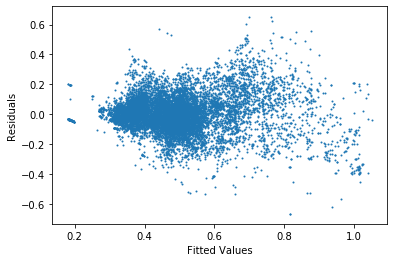

In [23]:
import matplotlib.pyplot as plt

plt.scatter(ngmod.fittedvalues, ngmod.resid, s=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

There is some evidence of heteroskedasticity, i.e., there is a shape to the plot, suggesting more variability on the right than on the left. 

**Question 5:** Transform the response using the log transform. Fit the same model as fit above in Question 1. Then refit excluding the predictor `month`. Which fit has a lower value of PRESS? **(4)**

In [27]:
import statsmodels.stats.outliers_influence as outliers_influence

natgascomplete['logavgprice'] = np.log(natgascomplete['avg_price_margin'])

ngmod2 = sm.OLS.from_formula(formula="logavgprice ~ month + n_gas_stations + region + sd_price + avg_price + min_price + max_price",
     data=natgascomplete).fit()

levs = outliers_influence.OLSInfluence(ngmod2).hat_matrix_diag

PRESS2 = ((ngmod2.resid / (1 - levs))**2).sum()
print(PRESS2)


ngmod3 = sm.OLS.from_formula(formula="logavgprice ~ n_gas_stations + region + sd_price + avg_price + min_price + max_price",
     data=natgascomplete).fit()

levs = outliers_influence.OLSInfluence(ngmod3).hat_matrix_diag

PRESS3 = ((ngmod3.resid / (1 - levs))**2).sum()
print(PRESS3)

806.2247337681106
805.587043412333


/Users/chadschafer/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  This is separate from the ipykernel package so we can avoid doing imports until


We find that the model that excludes `month` has lower PRESS, so that model is preferred based on this criterion. 